In [1]:
# ============================================================
# MODULE: Data Preprocessing (Jupyter Notebook - Single Cell)
# Project: Trainable Quantum Kernel QSVM for Seizure Detection
# Path: C:\Users\shanmugam\QUANTUM HACK\Epileptic Seizure Recognition.csv
# Output: Xtr(300,12), Xte(200,12), ytr(300,), yte(200,)
# ============================================================

import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# ----------------------------
# 1) SETTINGS
# ----------------------------
RANDOM_STATE = 42
N_TOTAL = 500
N_PER_CLASS = 250
TRAIN_SIZE = 300
TEST_SIZE = 200
N_QUBITS = 12  # PCA components = qubits

DATA_PATH = r"C:\Users\shanmugam\QUANTUM HACK\Epileptic Seizure Recognition.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Dataset not found at: {DATA_PATH}")

print("✅ Dataset path:", DATA_PATH)
print("✅ Settings:", {"N_TOTAL": N_TOTAL, "TRAIN_SIZE": TRAIN_SIZE, "TEST_SIZE": TEST_SIZE, "N_QUBITS": N_QUBITS})

# ----------------------------
# 2) LOAD DATA
# ----------------------------
df = pd.read_csv(DATA_PATH)

# Drop any index-like column
drop_cols = [c for c in df.columns if c.lower().startswith("unnamed")]
if drop_cols:
    df = df.drop(columns=drop_cols)
    print("🧹 Dropped columns:", drop_cols)

if "y" not in df.columns:
    raise ValueError("Column 'y' not found in dataset. Please check the label column name.")

X = df.drop(columns=["y"])
y_raw = df["y"].astype(int)

print("📌 Raw shape:", df.shape)
print("📌 Features shape:", X.shape)
print("📌 Label distribution (1–5):")
print(y_raw.value_counts().sort_index())

# ----------------------------
# 3) MULTI-CLASS → BINARY
#    1 -> Seizure (1)
#    2..5 -> Non-seizure (0)
# ----------------------------
y = (y_raw == 1).astype(int)
print("\n✅ Binary distribution (before balance):")
print(pd.Series(y).value_counts().rename(index={0:"Non-Seizure(0)", 1:"Seizure(1)"}))

# ----------------------------
# 4) CREATE BALANCED 500 (250/250)
# ----------------------------
df_bin = X.copy()
df_bin["y"] = y

df_seiz = df_bin[df_bin["y"] == 1]
df_non  = df_bin[df_bin["y"] == 0]

if len(df_seiz) < N_PER_CLASS or len(df_non) < N_PER_CLASS:
    raise ValueError(f"Not enough samples for balancing. Seizure={len(df_seiz)}, Non={len(df_non)}, required per class={N_PER_CLASS}")

df_seiz_s = df_seiz.sample(n=N_PER_CLASS, random_state=RANDOM_STATE)
df_non_s  = df_non.sample(n=N_PER_CLASS, random_state=RANDOM_STATE)

df_500 = pd.concat([df_seiz_s, df_non_s], axis=0).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

X_500 = df_500.drop(columns=["y"]).values
y_500 = df_500["y"].values

print("\n✅ Balanced dataset created:")
print("   X_500:", X_500.shape, " y_500:", y_500.shape)
print("   Class counts:", {0:int((y_500==0).sum()), 1:int((y_500==1).sum())})

# ----------------------------
# 5) TRAIN/TEST SPLIT (300/200) STRATIFIED
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_500, y_500,
    train_size=TRAIN_SIZE,
    test_size=TEST_SIZE,
    stratify=y_500,
    random_state=RANDOM_STATE
)

print("\n✅ Split done:")
print("   Train:", X_train.shape, " | Seizure:", int(y_train.sum()), " Non:", int((1-y_train).sum()))
print("   Test :", X_test.shape,  " | Seizure:", int(y_test.sum()),  " Non:", int((1-y_test).sum()))

# ----------------------------
# 6) SCALE + PCA → 12 (Quantum-ready)
# ----------------------------
preprocess = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=N_QUBITS, random_state=RANDOM_STATE))
])

Xtr = preprocess.fit_transform(X_train)
Xte = preprocess.transform(X_test)

pca = preprocess.named_steps["pca"]
explained = float(np.sum(pca.explained_variance_ratio_))

print("\n✅ Quantum-ready features:")
print("   Xtr:", Xtr.shape, "Xte:", Xte.shape)
print(f"   PCA explained variance (sum): {explained:.4f}")

# ----------------------------
# 7) SAVE PREPROCESSOR (OPTIONAL)
# ----------------------------
# You can save and reuse exactly the same PCA+Scaler later
# import joblib
# joblib.dump(preprocess, r"C:\Users\shanmugam\QUANTUM HACK\preprocess_scaler_pca12.pkl")

print("\n🎯 Final outputs available in memory:")
print("   Xtr, Xte, y_train, y_test, preprocess")

✅ Dataset path: C:\Users\shanmugam\QUANTUM HACK\Epileptic Seizure Recognition.csv
✅ Settings: {'N_TOTAL': 500, 'TRAIN_SIZE': 300, 'TEST_SIZE': 200, 'N_QUBITS': 12}
🧹 Dropped columns: ['Unnamed']
📌 Raw shape: (11500, 179)
📌 Features shape: (11500, 178)
📌 Label distribution (1–5):
y
1    2300
2    2300
3    2300
4    2300
5    2300
Name: count, dtype: int64

✅ Binary distribution (before balance):
y
Non-Seizure(0)    9200
Seizure(1)        2300
Name: count, dtype: int64

✅ Balanced dataset created:
   X_500: (500, 178)  y_500: (500,)
   Class counts: {0: 250, 1: 250}

✅ Split done:
   Train: (300, 178)  | Seizure: 150  Non: 150
   Test : (200, 178)  | Seizure: 100  Non: 100

✅ Quantum-ready features:
   Xtr: (300, 12) Xte: (200, 12)
   PCA explained variance (sum): 0.6060

🎯 Final outputs available in memory:
   Xtr, Xte, y_train, y_test, preprocess


In [2]:
# ============================================================
# SAVE TRAIN AND TEST DATASETS
# ============================================================

import os
import pandas as pd
import joblib

SAVE_DIR = r"C:\Users\shanmugam\QUANTUM HACK"

# Ensure directory exists
os.makedirs(SAVE_DIR, exist_ok=True)

# ----------------------------
# Convert arrays to DataFrame
# ----------------------------

# Create feature column names
feature_cols = [f"PC_{i+1}" for i in range(Xtr.shape[1])]

# Train DataFrame
train_df = pd.DataFrame(Xtr, columns=feature_cols)
train_df["label"] = y_train

# Test DataFrame
test_df = pd.DataFrame(Xte, columns=feature_cols)
test_df["label"] = y_test

# ----------------------------
# Save CSV files
# ----------------------------

train_path = os.path.join(SAVE_DIR, "train_data.csv")
test_path = os.path.join(SAVE_DIR, "test_data.csv")

train_df.to_csv(train_path, index=False)
test_df.to_csv(test_path, index=False)

# ----------------------------
# Save preprocessing pipeline
# ----------------------------

pipeline_path = os.path.join(SAVE_DIR, "preprocess_pipeline.pkl")
joblib.dump(preprocess, pipeline_path)

print("✅ Files saved successfully!")
print("Train file:", train_path)
print("Test file :", test_path)
print("Pipeline  :", pipeline_path)

✅ Files saved successfully!
Train file: C:\Users\shanmugam\QUANTUM HACK\train_data.csv
Test file : C:\Users\shanmugam\QUANTUM HACK\test_data.csv
Pipeline  : C:\Users\shanmugam\QUANTUM HACK\preprocess_pipeline.pkl


In [3]:
# ============================================================
# PCA-12 CONVERSION + SAVE DATASET
# ============================================================

import os
import numpy as np
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ----------------------------
# SETTINGS
# ----------------------------
DATA_PATH = r"C:\Users\shanmugam\QUANTUM HACK\Epileptic Seizure Recognition.csv"
SAVE_DIR = r"C:\Users\shanmugam\QUANTUM HACK"

RANDOM_STATE = 42
N_PER_CLASS = 250
N_COMPONENTS = 12

os.makedirs(SAVE_DIR, exist_ok=True)

# ----------------------------
# 1. LOAD DATA
# ----------------------------
df = pd.read_csv(DATA_PATH)

# Drop index column if exists
drop_cols = [c for c in df.columns if c.lower().startswith("unnamed")]
if drop_cols:
    df = df.drop(columns=drop_cols)

# Features and labels
X = df.drop(columns=["y"])
y_raw = df["y"].astype(int)

# ----------------------------
# 2. BINARY CONVERSION
# ----------------------------
y = (y_raw == 1).astype(int)

# ----------------------------
# 3. BALANCE DATASET (250/250)
# ----------------------------
df_bin = X.copy()
df_bin["label"] = y

df_seiz = df_bin[df_bin["label"] == 1].sample(n=N_PER_CLASS, random_state=RANDOM_STATE)
df_non  = df_bin[df_bin["label"] == 0].sample(n=N_PER_CLASS, random_state=RANDOM_STATE)

df_bal = pd.concat([df_seiz, df_non]).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

X_bal = df_bal.drop(columns=["label"]).values
y_bal = df_bal["label"].values

print("Balanced shape:", X_bal.shape)
print("Class distribution:", {0:int((y_bal==0).sum()), 1:int((y_bal==1).sum())})

# ----------------------------
# 4. TRAIN / TEST SPLIT
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal,
    train_size=300,
    test_size=200,
    stratify=y_bal,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape, "Test:", X_test.shape)

# ----------------------------
# 5. STANDARDIZE
# ----------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ----------------------------
# 6. PCA → 12 COMPONENTS
# ----------------------------
pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print("PCA Train shape:", X_train_pca.shape)
print("PCA Test shape :", X_test_pca.shape)
print("Explained variance ratio sum:", round(np.sum(pca.explained_variance_ratio_),4))

# ----------------------------
# 7. SAVE FILES
# ----------------------------

# Column names
cols = [f"PC_{i+1}" for i in range(N_COMPONENTS)]

train_df = pd.DataFrame(X_train_pca, columns=cols)
train_df["label"] = y_train

test_df = pd.DataFrame(X_test_pca, columns=cols)
test_df["label"] = y_test

train_path = os.path.join(SAVE_DIR, "train_pca12.csv")
test_path  = os.path.join(SAVE_DIR, "test_pca12.csv")

train_df.to_csv(train_path, index=False)
test_df.to_csv(test_path, index=False)

# Save scaler & PCA model
joblib.dump(scaler, os.path.join(SAVE_DIR, "scaler_model.pkl"))
joblib.dump(pca, os.path.join(SAVE_DIR, "pca_model.pkl"))

print("\n✅ Files Saved Successfully!")
print("Train PCA File:", train_path)
print("Test PCA File :", test_path)
print("Scaler Model  :", os.path.join(SAVE_DIR, "scaler_model.pkl"))
print("PCA Model     :", os.path.join(SAVE_DIR, "pca_model.pkl"))

Balanced shape: (500, 178)
Class distribution: {0: 250, 1: 250}
Train: (300, 178) Test: (200, 178)
PCA Train shape: (300, 12)
PCA Test shape : (200, 12)
Explained variance ratio sum: 0.606

✅ Files Saved Successfully!
Train PCA File: C:\Users\shanmugam\QUANTUM HACK\train_pca12.csv
Test PCA File : C:\Users\shanmugam\QUANTUM HACK\test_pca12.csv
Scaler Model  : C:\Users\shanmugam\QUANTUM HACK\scaler_model.pkl
PCA Model     : C:\Users\shanmugam\QUANTUM HACK\pca_model.pkl


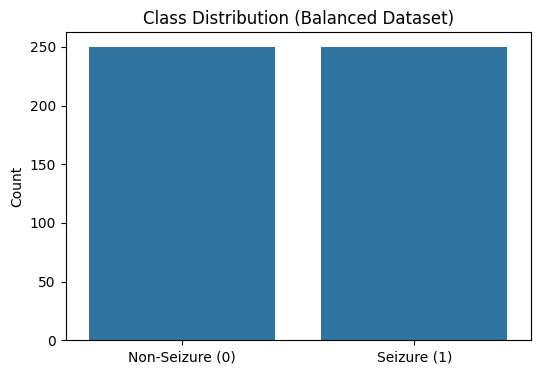

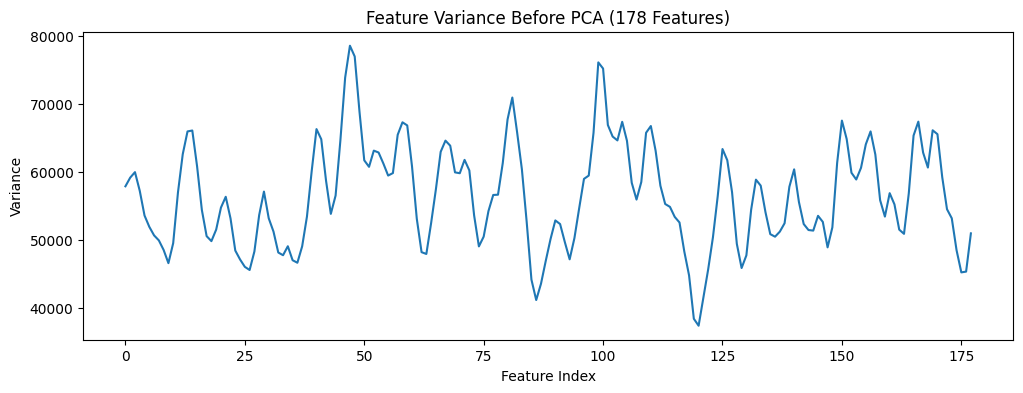

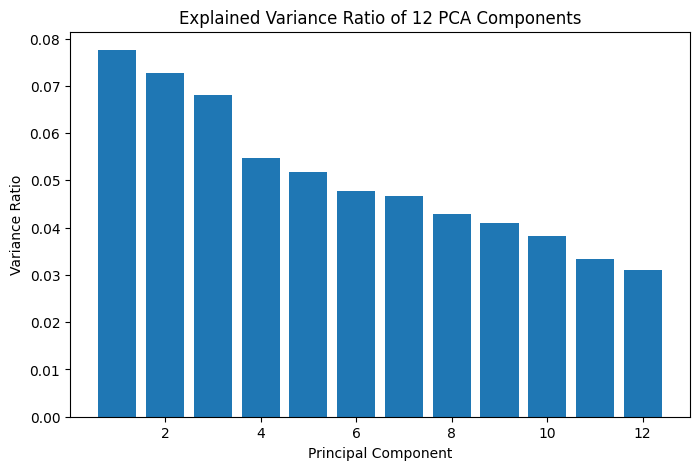

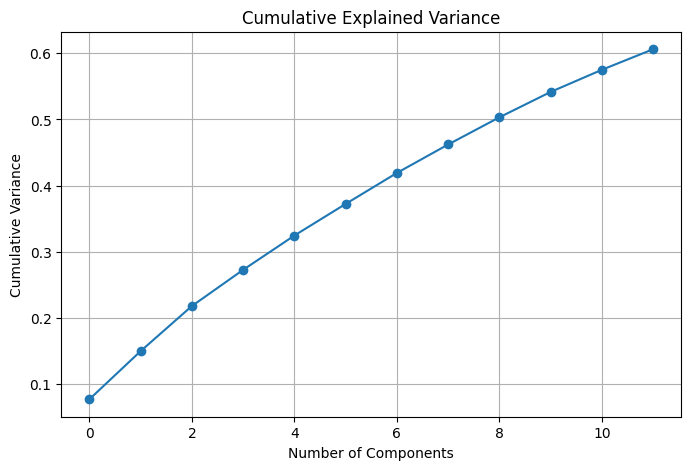

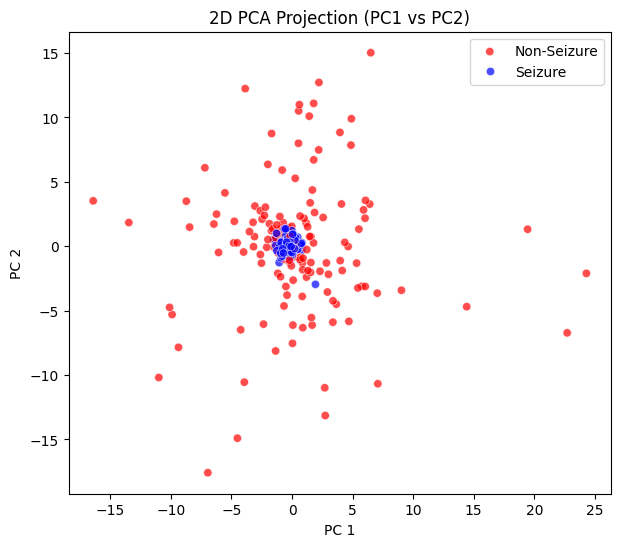

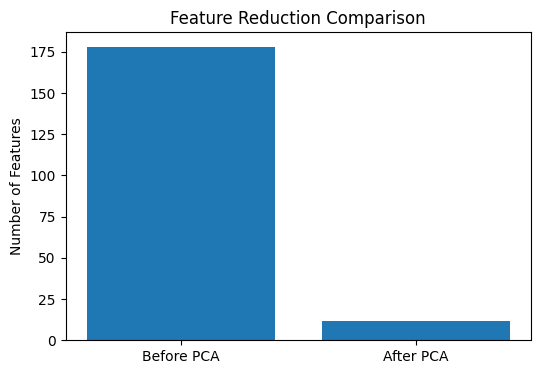

In [5]:
# ============================================================
# VISUALIZATION: BEFORE & AFTER PCA
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Use the balanced dataset before PCA
# (Assumes df_bal, X_train_scaled, X_train_pca, y_train already exist)

# ----------------------------
# 1️⃣ Class Distribution
# ----------------------------
plt.figure(figsize=(6,4))
sns.countplot(x=y_bal)
plt.title("Class Distribution (Balanced Dataset)")
plt.xticks([0,1], ["Non-Seizure (0)", "Seizure (1)"])
plt.ylabel("Count")
plt.show()

# ----------------------------
# 2️⃣ Feature Variance BEFORE PCA
# ----------------------------
feature_variances = np.var(X_bal, axis=0)

plt.figure(figsize=(12,4))
plt.plot(feature_variances)
plt.title("Feature Variance Before PCA (178 Features)")
plt.xlabel("Feature Index")
plt.ylabel("Variance")
plt.show()

# ----------------------------
# 3️⃣ PCA Explained Variance
# ----------------------------
explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(8,5))
plt.bar(range(1, len(explained_variance)+1), explained_variance)
plt.title("Explained Variance Ratio of 12 PCA Components")
plt.xlabel("Principal Component")
plt.ylabel("Variance Ratio")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(np.cumsum(explained_variance), marker='o')
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.grid()
plt.show()

# ----------------------------
# 4️⃣ 2D PCA Scatter Plot
# ----------------------------
plt.figure(figsize=(7,6))
sns.scatterplot(
    x=X_train_pca[:,0],
    y=X_train_pca[:,1],
    hue=y_train,
    palette=["blue", "red"],
    alpha=0.7
)
plt.title("2D PCA Projection (PC1 vs PC2)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.legend(["Non-Seizure", "Seizure"])
plt.show()

# ----------------------------
# 5️⃣ Feature Count Comparison
# ----------------------------
plt.figure(figsize=(6,4))
plt.bar(["Before PCA", "After PCA"], [X_bal.shape[1], X_train_pca.shape[1]])
plt.title("Feature Reduction Comparison")
plt.ylabel("Number of Features")
plt.show()